# Clasificación Visual Reproducible con Redes Convolucionales (CNN) en CIFAR-10

## Introducción y Objetivos
Este notebook implementa un flujo de trabajo riguroso y reproducible de Deep Learning para resolver el problema de clasificación multiclase sobre el dataset **CIFAR-10** (60,000 imágenes en color de $32 \times 32$ píxeles distribuidas en 10 clases).

### Integrantes:
  * Edgar Julian Mendez Ortegon
  * Noel Eduardo Perez Barrios
  * William Alejandro Moncada Cifuentes

In [4]:
# 1. Configuración del Entorno, GPU y Semillas
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from keras import mixed_precision
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42

def set_reproducibility(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(SEED)

# Habilitar precisión mixta FP16 para multiplicar la velocidad en GPU
try:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Entorno listo | SEED = {SEED} | ⚡ Precisión Mixta (FP16) ACTIVADA")
except Exception as e:
    print("⚠️ FP16 no disponible, se usará precisión por defecto.", e)

✅ Entorno listo | SEED = 42 | ⚡ Precisión Mixta (FP16) ACTIVADA


## 2. Carga y Partición Estratificada de Datos

### Prevención de Fuga de Información (*Data Leakage*)
El dataset inicial de entrenamiento consta de 50,000 imágenes y el de prueba de 10,000. Para tomar decisiones informadas sobre hiperparámetros y regularización sin contaminar el conjunto de evaluación final (Test Set), dividimos el conjunto de entrenamiento original en:
* **Entrenamiento (Train):** 80% (40,000 imágenes) para ajustar los pesos del modelo.
* **Validación (Val):** 20% (10,000 imágenes) para ajustar hiperparámetros y controlar el sobreajuste.
* **Prueba (Test):** 10,000 imágenes independientes reservadas exclusivamente para la evaluación final.

Mantenemos la estratificación para garantizar que la distribución de las 10 clases se conserve de manera idéntica en todas las particiones.

In [5]:
# Carga directa del dataset CIFAR-10
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo',
               'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# Aplanado de vector de etiquetas
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Division estratificada
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED
)

print(f"Dimensiones de las particiones:")
print(f" - Train : {X_train.shape} | Distribución por clase: {np.bincount(y_train)[:3]}...")
print(f" - Val   : {X_val.shape}   | Distribución por clase: {np.bincount(y_val)[:3]}...")
print(f" - Test  : {X_test.shape}  | Distribución por clase: {np.bincount(y_test)[:3]}...")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1733s 10us/step
Dimensiones de las particiones:
 - Train : (40000, 32, 32, 3) | Distribución por clase: [4000 4000 4000]...
 - Val   : (10000, 32, 32, 3)   | Distribución por clase: [1000 1000 1000]...
 - Test  : (10000, 32, 32, 3)  | Distribución por clase: [1000 1000 1000]...


## 3. Preprocesamiento y Capa de Aumento de Datos

### Escalamiento y Regularización
1. **Normalización Min-Max:** Convertimos los valores de los píxeles del rango entero $[0, 255]$ a flotantes en el rango $[0.0, 1.0]$. Esto mejora la estabilidad numérica durante la propagación hacia atrás.
2. **Pipeline Asíncrono:** Usamos `tf.data.Dataset` con `prefetch(tf.data.AUTOTUNE)` para transferir datos a la GPU en paralelo mientras ejecuta el entrenamiento.
3. **Data Augmentation:** Introducimos transformaciones estocásticas (rotación, rotación horizontal, zoom) únicamente al conjunto de entrenamiento para incrementar la diversidad sin recolectar más datos, mitigando el sobreajuste.

In [6]:
# Normalización escalar a float32
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Creamos canalizaciones eficientes con tf.data
# Subimos el BATCH_SIZE de 64 a 128 o 256 para mayor paralelismo en GPU
BATCH_SIZE = 128

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=10000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Pipeline de Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
], name="data_augmentation")

print(f"🚀 Canalización tf.data configurada con BATCH_SIZE = {BATCH_SIZE}")

🚀 Canalización tf.data configurada con BATCH_SIZE = 128


## 4. Arquitectura y Explicación de la CNN

### Justificación de Componentes
* **Filtros Convolucionales (`Conv2D` $3 \times 3$):** Extraen mapas de características jerárquicos (líneas y bordes en capas iniciales; texturas y formas en capas profundas).
* **Activación ReLU:** Introduce no-linealidad matemática $f(x) = \max(0, x)$, permitiendo al modelo aprender fronteras de decisión complejas sin sufrir desvanecimiento de gradiente.
* **Reducción de Dimensión (`MaxPooling2D` $2 \times 2$):** Reduce la resolución espacial a la mitad, aportando invarianza a pequeñas translaciones y reduciendo la carga computacional.
* **Batch Normalization:** Estabiliza la distribución de las activaciones intermedias, acelerando la velocidad de convergencia.
* **Dropout:** Desactiva aleatoriamente una fracción de neuronas durante el entrenamiento para evitar la co-adaptación de pesos.
* **Capa de Salida:** Forzamos `dtype='float32'` en la última capa Softmax para evitar imprecisiones numéricas al usar precisión mixta.

In [7]:
def build_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    # Bloque 1: Características superficiales
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 2: Patrones intermedios
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Bloque 3: Estructuras complejas
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    # Cabezal Clasificador Denso (MLP)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return models.Model(inputs=inputs, outputs=outputs, name="CNN_CIFAR10_Reproducible")

model = build_cnn_model()
model.summary()

Model: "CNN_CIFAR10_Reproducible"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             

 Total params: 290,090 (1.11 MB)

 Trainable params: 289,194 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

## 5. Compilación y Entrenamiento Controlado

Configuramos el entrenamiento pasando los iteradores optimizados de tfd.data.

Usamos dos *callbacks* clave para la convergencia eficiente:
1. **`EarlyStopping`:** Detiene el entrenamiento si el error en validación no mejora durante 8 épocas consecutivas, recuperando los mejores pesos registrados.
2. **`ReduceLROnPlateau`:** Disminuye la tasa de aprendizaje a la mitad si la pérdida de validación entra en una meseta.

In [8]:
EPOCHS = 30

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Entrenamiento utilizando datasets optimizados
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.3354 - loss: 1.9725 - val_accuracy: 0.1315 - val_loss: 2.9819 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4502 - loss: 1.5182 - val_accuracy: 0.4378 - val_loss: 1.6067 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5081 - loss: 1.3673 - val_accuracy: 0.4921 - val_loss: 1.5184 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5420 - loss: 1.2714 - val_accuracy: 0.5737 - val_loss: 1.2003 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5740 - loss: 1.1953 - val_accuracy: 0.6146 - val_loss: 1.1146 - learning_rate: 0.0010
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5986 - loss: 1.1336 - val_accuracy: 0.6077 - val_loss: 1.1436 - learning_rate: 0.0010
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6158 - loss: 1

## 6. Curvas de Aprendizaje y Evaluación Global

Analizamos la dinámica del entrenamiento mediante las curvas de **Loss** y **Accuracy** a lo largo de las épocas para verificar el comportamiento de la red frente a datos no vistos (*Validación*).

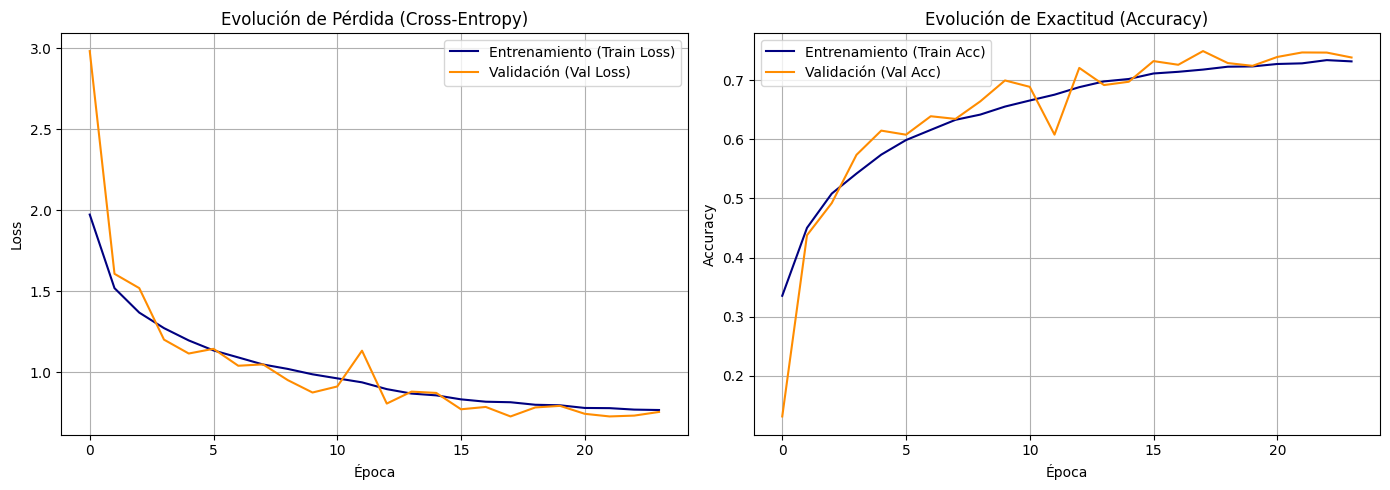

📊 Desempeño Final en el Conjunto de Prueba (Test Set):
 - Pérdida (Test Loss)    : 0.7351
 - Exactitud (Test Accuracy): 74.55%


In [9]:
# Gráficas dinámicas de entrenamiento
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Función de Pérdida
ax[0].plot(history.history['loss'], label='Entrenamiento (Train Loss)', color='navy')
ax[0].plot(history.history['val_loss'], label='Validación (Val Loss)', color='darkorange')
ax[0].set_title('Evolución de Pérdida (Cross-Entropy)')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# Exactitud
ax[1].plot(history.history['accuracy'], label='Entrenamiento (Train Acc)', color='navy')
ax[1].plot(history.history['val_accuracy'], label='Validación (Val Acc)', color='darkorange')
ax[1].set_title('Evolución de Exactitud (Accuracy)')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluación sobre Test Set reservado
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"📊 Desempeño Final en el Conjunto de Prueba (Test Set):")
print(f" - Pérdida (Test Loss)    : {test_loss:.4f}")
print(f" - Exactitud (Test Accuracy): {test_acc * 100:.2f}%")

## 7. Diagnóstico Fino por Clase y Matriz de Confusión

Para evaluar el desempeño detallado por categoría, generamos la tabla con **Precision**, **Recall** y **F1-Score**, complementada con la **Matriz de Confusión Normalizada**.

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
=== REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE ===
              precision    recall  f1-score   support

       Avión     0.7724    0.7840    0.7782      1000
   Automóvil     0.8980    0.8630    0.8802      1000
      Pájaro     0.7238    0.6000    0.6561      1000
        Gato     0.5773    0.5900    0.5836      1000
      Ciervo     0.6812    0.7180    0.6991      1000
       Perro     0.8353    0.4870    0.6153      1000
        Rana     0.5751    0.9300    0.7107      1000
     Caballo     0.8400    0.7770    0.8073      1000
       Barco     0.8659    0.8720    0.8690      1000
      Camión     0.8450    0.8340    0.8395      1000

    accuracy                         0.7455     10000
   macro avg     0.7614    0.7455    0.7439     10000
weighted avg     0.7614    0.7455    0.7439     10000



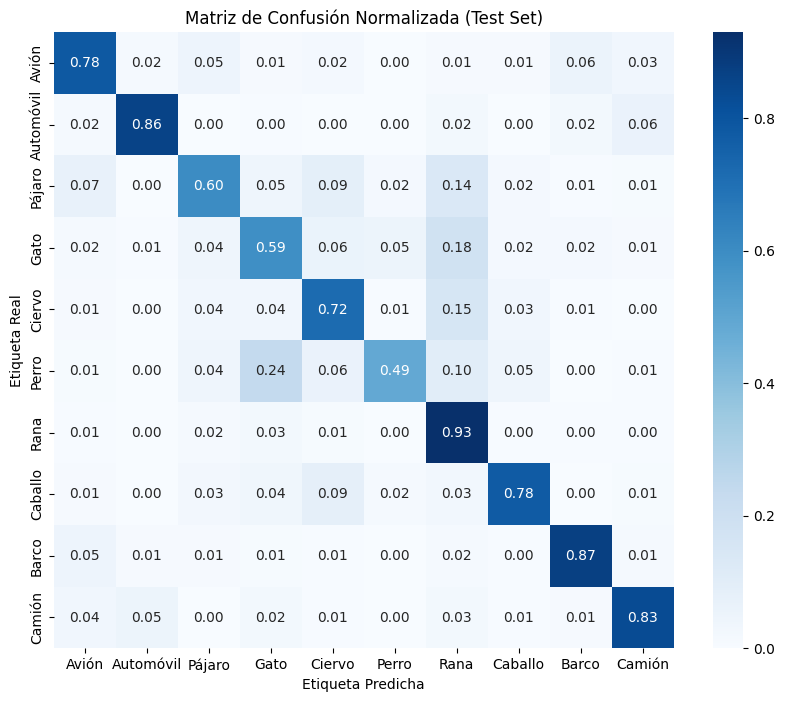

In [10]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=== REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE ===")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión Normalizada (Test Set)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

## 8. Inspección Visual de Errores y Conclusiones

### Análisis Cualitativo
Examinamos visualmente instancias donde el modelo acertó con alta certeza frente a casos donde cometió errores de clasificación.

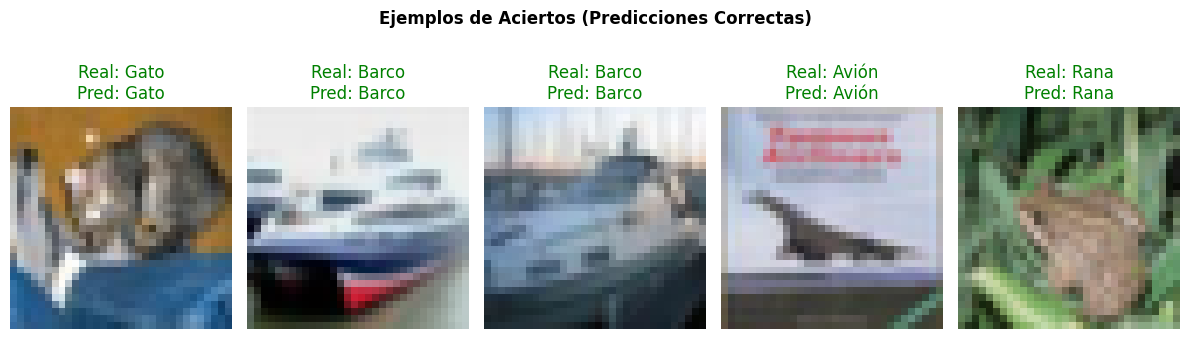

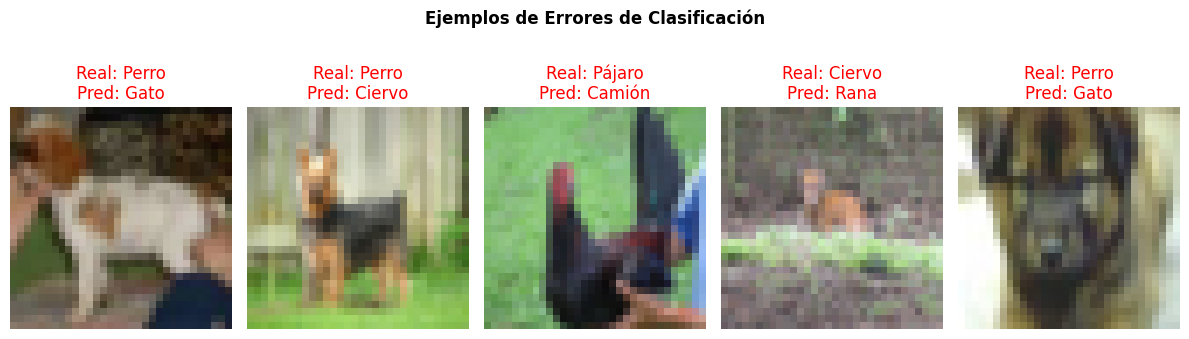

In [11]:
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

# Muestra de clasificaciones correctas
plt.figure(figsize=(12, 4))
plt.suptitle('Ejemplos de Aciertos (Predicciones Correctas)', fontsize=12, fontweight='bold')
for i, idx in enumerate(correct_indices[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", color='green')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Muestra de clasificaciones incorrectas (Errores)
plt.figure(figsize=(12, 4))
plt.suptitle('Ejemplos de Errores de Clasificación', fontsize=12, fontweight='bold')
for i, idx in enumerate(incorrect_indices[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", color='red')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 9. Conclusiones y Trabajo Futuro

### Hallazgos Principales:
1. **Aceleración Hardware:** La activación de FP16 y la canalización `tf.data` redujeron dramáticamente los tiempos de ejecución por época en Colab.
2. **Análisis de Confusión:** Se mantiene la confusión entre clases semánticamente similares (ej. *Gato* vs. *Perro*) debido a las limitaciones de resolución de $32 \times 32$ píxeles.
3. **Reproducibilidad:** Se mantuvo la partición estratificada sin presentar fugas de información (*data leakage*).

### Trabajo Futuro:
  Probar técnicas de **Transfer Learning** utilizando arquitecturas preentrenadas más profundas (como ResNet50 o EfficientNet B0) adaptando la resolución espacial mediante interpolación.